In [2]:
import pandas as pd

mpg = pd.read_csv('./mpg.csv')

In [4]:
mpg.head()

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,category
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact


In [6]:
mpg.info()

<class 'pandas.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   manufacturer  234 non-null    str    
 1   model         234 non-null    str    
 2   displ         234 non-null    float64
 3   year          234 non-null    int64  
 4   cyl           234 non-null    int64  
 5   trans         234 non-null    str    
 6   drv           234 non-null    str    
 7   cty           234 non-null    int64  
 8   hwy           234 non-null    int64  
 9   fl            234 non-null    str    
 10  category      234 non-null    str    
dtypes: float64(1), int64(4), str(6)
memory usage: 20.2 KB


In [7]:
mpg.describe()

,displ,year,cyl,cty,hwy
count,234.000000,234.000000,234.000000,234.000000,234.000000
mean,3.471795,2003.500000,5.888889,16.858974,23.440171
std,1.291959,4.509646,1.611534,4.255946,5.954643
min,1.600000,1999.000000,4.000000,9.000000,12.000000
25%,2.400000,1999.000000,4.000000,14.000000,18.000000
50%,3.300000,2003.500000,6.000000,17.000000,24.000000
75%,4.600000,2008.000000,8.000000,19.000000,27.000000
max,7.000000,2008.000000,8.000000,35.000000,44.000000


In [9]:
# 파생열 만들기
# 통합 연비가 된다
mpg['total'] = (mpg['cty'] + mpg['hwy']) / 2
mpg.head()

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,category,total
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact,23.5
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact,25.0
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact,25.5
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact,25.5
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact,21.0


In [10]:
sum(mpg['total'])/len(mpg)

20.14957264957265

In [11]:
mpg['total'].mean()

np.float64(20.14957264957265)

In [13]:
mpg['total'].describe()

count    234.000000
mean      20.149573
std        5.050290
min       10.500000
25%       15.500000
50%       20.500000
75%       23.500000
max       39.500000
Name: total, dtype: float64

In [15]:
import matplotlib.pyplot as plt

<Axes: ylabel='Frequency'>

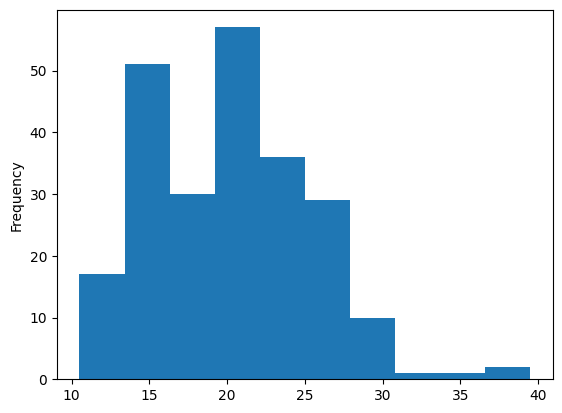

In [16]:
mpg['total'].plot.hist()

In [21]:
# 연피가 20키로 이상이면 pass, 그렇지 않으면 fail 부여
import numpy as np
mpg['test'] = np.where(mpg['total'] >= 20, 'pass', 'fail' )
mpg

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,category,total,test
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact,23.5,pass
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact,25.0,pass
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact,25.5,pass
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact,25.5,pass
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact,21.0,pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...
229,volkswagen,passat,2.0,2008,4,auto(s6),f,19,28,p,midsize,23.5,pass
230,volkswagen,passat,2.0,2008,4,manual(m6),f,21,29,p,midsize,25.0,pass
231,volkswagen,passat,2.8,1999,6,auto(l5),f,16,26,p,midsize,21.0,pass
232,volkswagen,passat,2.8,1999,6,manual(m5),f,18,26,p,midsize,22.0,pass


In [23]:
# pass, fail 세는 함수
count_test = mpg['test'].value_counts()

<Axes: xlabel='test'>

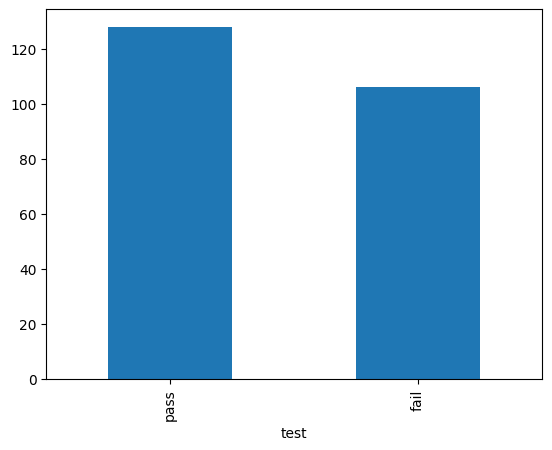

In [24]:
count_test.plot.bar()

<Axes: xlabel='test'>

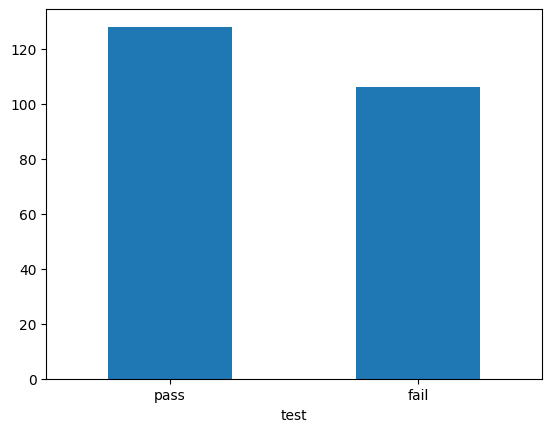

In [25]:
count_test.plot.bar(rot=0)


In [26]:
mpg['grade'] = np.where(mpg['total']>=30, 'A',
                        np.where(mpg['total']>=20, 'B', 'C'))
mpg.head()

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,category,total,test,grade
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact,23.5,pass,B
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact,25.0,pass,B
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact,25.5,pass,B
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact,25.5,pass,B
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact,21.0,pass,B


<Axes: xlabel='grade'>

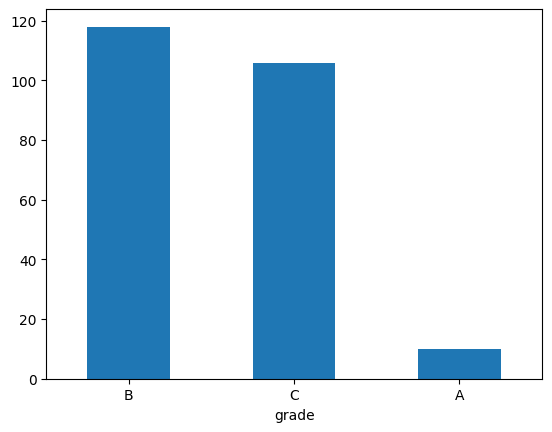

In [ ]:
# a bc 순서대로 하려면 sort.index()를 사용해야된다
count_grade = mpg['grade'].value_counts()
count_grade.plot.bar(rot=0)


<Axes: xlabel='grade'>

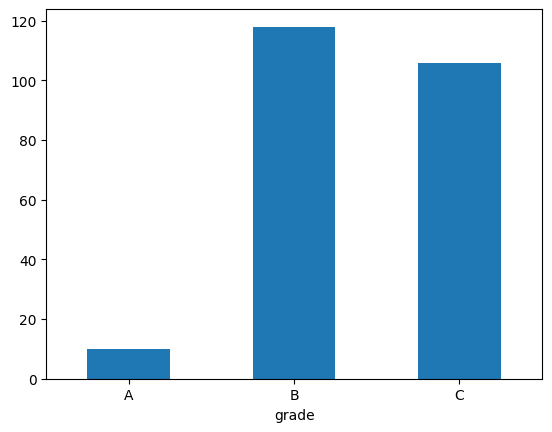

In [29]:
# 순서를 정해주는 .sort_index()
count_grade = mpg['grade'].value_counts().sort_index()
count_grade.plot.bar(rot=0)

In [34]:
# 제조회사 및 구동방식별 cty 평균 구하기 별 << group by
# mpg.groupby(['manufacturer', 'drv'])['cty'].mean()
mpg.groupby(['manufacturer', 'drv']) \
    .agg(mean_city = ('cty', 'mean'))

mean_city
manufacturer drv           
audi         4    16.818182
             f    18.857143
chevrolet    4    12.500000
             f    18.800000
             r    14.100000
dodge        4    12.000000
             f    15.818182
ford         4    13.307692
             r    14.750000
honda        f    24.444444
hyundai      f    18.642857
jeep         4    13.500000
land rover   4    11.500000
lincoln      r    11.333333
mercury      4    13.250000
nissan       4    13.750000
             f    20.000000
pontiac      f    17.000000
subaru       4    19.285714
toyota       4    14.933333
             f    21.368421
volkswagen   f    20.925926

In [74]:
#suv 추출
#합산 연비 변수 만들기
# 제조 회사별로 분리
# 합산 연비 평균 구하기
# 내림차순 정렬
mpg = pd.read_csv('./mpg.csv')

In [36]:
mpg

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,category
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact
...,...,...,...,...,...,...,...,...,...,...,...
229,volkswagen,passat,2.0,2008,4,auto(s6),f,19,28,p,midsize
230,volkswagen,passat,2.0,2008,4,manual(m6),f,21,29,p,midsize
231,volkswagen,passat,2.8,1999,6,auto(l5),f,16,26,p,midsize
232,volkswagen,passat,2.8,1999,6,manual(m5),f,18,26,p,midsize


In [42]:
#suv 추출
#합산 연비 변수 만들기
# 제조 회사별로 분리
# 합산 연비 평균 구하기
# 내림차순 정렬
mpg['total'] = (mpg['cty'] + mpg['hwy']) / 2
mpg 


,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,category,total
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact,23.5
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact,25.0
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact,25.5
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact,25.5
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...
229,volkswagen,passat,2.0,2008,4,auto(s6),f,19,28,p,midsize,23.5
230,volkswagen,passat,2.0,2008,4,manual(m6),f,21,29,p,midsize,25.0
231,volkswagen,passat,2.8,1999,6,auto(l5),f,16,26,p,midsize,21.0
232,volkswagen,passat,2.8,1999,6,manual(m5),f,18,26,p,midsize,22.0


In [59]:
mpg_suv = mpg['category'] == 'suv'
mpg_suv

0      False
1      False
2      False
3      False
4      False
       ...  
229    False
230    False
231    False
232    False
233    False
Name: category, Length: 234, dtype: bool

In [87]:
mpg[mpg_suv]
mpg['total'] = (mpg['cty'] + mpg['hwy']) / 2
answer = mpg[mpg_suv].groupby('manufacturer')['total'].mean()
answer1 =  pd.Series(answer)
answer1
#mpg.groupby(['manufacturer', 'drv']) \
#    .agg(mean_city = ('cty', 'mean'))


manufacturer
chevrolet     14.888889
dodge         13.928571
ford          15.333333
jeep          15.562500
land rover    14.000000
lincoln       14.166667
mercury       15.625000
nissan        15.875000
subaru        21.916667
toyota        16.312500
Name: total, dtype: float64

In [82]:
a = mpg.query('category=="suv"') \
    .assign(total = ((mpg['hwy']+mpg['cty'])/2)) \
    .groupby('manufacturer') \
    .agg(mean_tot = ('total','mean')) \
    .sort_values('mean_tot', ascending=False)\
    .head()
a

,mean_tot
manufacturer,
subaru,21.916667
toyota,16.312500
nissan,15.875000
mercury,15.625000
jeep,15.562500


In [78]:
a = mpg.query('category=="suv"')